# Ruitenwissermechanisme zonder stang 6 en 7

In deze versie zijn stang 6 en stang 7, dus de lus `D-F-G-H`, verwijderd. De rest van het model blijft zo veel mogelijk hetzelfde: dezelfde inputbeweging, massa-aanpak, zwaartekracht, wisserwrijving, scharnierwrijving en inverse-dynamica-opbouw. De onbalanskrachten en het onbalansmoment worden nu via de vaste punten `A`, `D` en `I` doorgegeven aan het frame.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve

plt.rcParams.update({
    'figure.figsize': (8, 4),
    'axes.grid': True,
    'grid.alpha': 0.3,
})

In [2]:
# Link lengths [m]
r1 = 0.11
r2 = 0.99
r3 = 1.53
r4 = 1.01
r5 = 1.13

# Stang 6 en 7 zijn verwijderd. Deze variabelen blijven alleen bestaan zodat de
# functies dezelfde structuur/argumenten houden als in de oorspronkelijke notebook.
r6 = 0.0
r7 = 0.0

# Distances from the central link to its joints [m]
rDC = 0.16
rDF = 0.41  # niet meer gebruikt voor een echte stang, enkel compatibiliteit
rED = 0.28
rIJ = 0.28

# Fixed ground points [m]
grondA_x = 0.00
grondA_y = 0.00

grondD_x = 0.76
grondD_y = 0.66

grondH_x = 1.79  # verwijderd steunpunt; blijft enkel als referentie in de tekening/structuur
grondH_y = 0.01

grondI_x = 1.77
grondI_y = 0.66

# Derived distances between ground points [m]
rAD_x = abs(grondD_x - grondA_x)
rAD_y = abs(grondD_y - grondA_y)
rDI_x = abs(grondD_x - grondI_x)
rDI_y = abs(grondD_y - grondI_y)
rDH_x = abs(grondH_x - grondD_x)
rDH_y = abs(grondH_y - grondD_y)

# Prescribed input motion
omega = 4.2       # [rad/s], driver angular speed = about 40 rpm
t_begin = 0
nt_end = 2*np.pi/omega
Ts = 0.01
num_steps = int(np.ceil((nt_end - t_begin) / Ts))
t = np.linspace(t_begin, nt_end, num_steps + 1)

theta1_0 = np.deg2rad(65)
theta1 = theta1_0 + omega * t
dtheta1 = omega * np.ones_like(t)
ddtheta1 = np.zeros_like(t)

# Initial guesses for the remaining nonlinear position closure.
theta2_init = np.deg2rad(15)
theta3_init = np.deg2rad(115)
theta4_init = 0.0  # stang 6 verwijderd
theta5_init = 0.0  # stang 7 verwijderd
theta6_init = np.deg2rad(0)     # stang 4
theta7_init = np.deg2rad(120)   # stang 5

In [3]:
# Function to rotate a vector z over an angle theta:
def rotate_vector(z, theta):
    rotation_matrix = np.array([[np.cos(theta), -np.sin(theta)],
                                [np.sin(theta),  np.cos(theta)]])
    return np.dot(rotation_matrix, z)

# Define function to compute "gap" in position closure.
# De structuur blijft gelijk, maar de sluitingsvergelijkingen van D-F-G-H zijn verwijderd.
def loop_closure_eqs(theta_init, theta1, r1, r2, r3, r4, r5, r6, r7, rDC, rDF, rED, rIJ, rAD_x, rAD_y, rDI_x, rDI_y):
    theta2 = theta_init[0]
    theta3 = theta_init[1]
    theta6 = theta_init[2]
    theta7 = theta_init[3]

    F1 = r1 * np.cos(theta1) + r2 * np.cos(theta2) + rDC * np.cos(theta3) - rAD_x
    F2 = r1 * np.sin(theta1) + r2 * np.sin(theta2) + rDC * np.sin(theta3) - rAD_y

    F3 = rED * np.cos(theta3) + r4 * np.cos(theta6) - rIJ * np.cos(theta7) - rDI_x
    F4 = rED * np.sin(theta3) + r4 * np.sin(theta6) - rIJ * np.sin(theta7) - rDI_y

    return [F1, F2, F3, F4]

In [4]:
# calculating unknown angles at time zero
def angles_at_time_zero(r1, r2, r3, r4, r5, r6, r7, rDC, rDF, rED, rIJ, rAD_x, rAD_y, rDI_x, rDI_y, theta1, dtheta1, ddtheta1, theta2_init, theta3_init,theta4_init,theta5_init,theta6_init,theta7_init, t):
    optim_options = {"full_output": True}
    k = 0
    x, _, ier, message = fsolve(
        lambda x: loop_closure_eqs(x, theta1[k], r1, r2, r3, r4, r5, r6, r7, rDC, rDF, rED, rIJ, rAD_x, rAD_y, rDI_x, rDI_y),
        [theta2_init, theta3_init, theta6_init, theta7_init],
        **optim_options
    )
    if ier != 1:
        print("The fsolve exit flag was not 1, probably no convergence!")
        print(message)

    theta2 = x[0]
    theta3 = x[1]
    theta4 = 0.0
    theta5 = 0.0
    theta6 = x[2]
    theta7 = x[3]
    return theta2, theta3, theta4, theta5, theta6, theta7

theta2_0, theta3_0, theta4_0, theta5_0, theta6_0, theta7_0 = angles_at_time_zero(
    r1, r2, r3, r4, r5, r6, r7, rDC, rDF, rED, rIJ,
    rAD_x, rAD_y, rDI_x, rDI_y, theta1, dtheta1, ddtheta1,
    theta2_init, theta3_init, theta4_init, theta5_init, theta6_init, theta7_init, t
)
print('beginstand zonder stang 6 en 7')
print(f'theta2 = {np.rad2deg(theta2_0):.2f} deg')
print(f'theta3 = {np.rad2deg(theta3_0):.2f} deg')
print(f'theta6 = {np.rad2deg(theta6_0):.2f} deg')
print(f'theta7 = {np.rad2deg(theta7_0):.2f} deg')

beginstand zonder stang 6 en 7
theta2 = 29.86 deg
theta3 = 155.07 deg
theta6 = 0.00 deg
theta7 = 155.07 deg


In [5]:
# Function to compute the kinematics
def kinematics(r1, r2, r3, r4, r5, r6, r7, rDC, rDF, rED, rIJ, rAD_x, rAD_y, rDI_x, rDI_y, theta1, dtheta1, ddtheta1, theta2_init, theta3_init,theta4_init,theta5_init,theta6_init,theta7_init, t):
    optim_options = {"full_output": True}

    theta2 = np.zeros_like(t)
    theta3 = np.zeros_like(t)
    theta4 = np.zeros_like(t)
    theta5 = np.zeros_like(t)
    theta6 = np.zeros_like(t)
    theta7 = np.zeros_like(t)

    dtheta2 = np.zeros_like(t)
    dtheta3 = np.zeros_like(t)
    dtheta4 = np.zeros_like(t)
    dtheta5 = np.zeros_like(t)
    dtheta6 = np.zeros_like(t)
    dtheta7 = np.zeros_like(t)

    ddtheta2 = np.zeros_like(t)
    ddtheta3 = np.zeros_like(t)
    ddtheta4 = np.zeros_like(t)
    ddtheta5 = np.zeros_like(t)
    ddtheta6 = np.zeros_like(t)
    ddtheta7 = np.zeros_like(t)

    cond = np.zeros_like(t)
    fsolve_failures = 0

    for k, time in enumerate(t):
        x, _, ier, message = fsolve(
            lambda x: loop_closure_eqs(x, theta1[k], r1, r2, r3, r4, r5, r6, r7, rDC, rDF, rED, rIJ, rAD_x, rAD_y, rDI_x, rDI_y),
            [theta2_init, theta3_init, theta6_init, theta7_init],
            **optim_options
        )
        if ier != 1:
            fsolve_failures += 1

        theta2[k] = x[0]
        theta3[k] = x[1]
        theta4[k] = 0.0
        theta5[k] = 0.0
        theta6[k] = x[2]
        theta7[k] = x[3]

        A = np.array([
            [-r2*np.sin(theta2[k]), -rDC*np.sin(theta3[k]), 0, 0],
            [ r2*np.cos(theta2[k]),  rDC*np.cos(theta3[k]), 0, 0],
            [0, -rED*np.sin(theta3[k]), -r4*np.sin(theta6[k]),  rIJ*np.sin(theta7[k])],
            [0,  rED*np.cos(theta3[k]),  r4*np.cos(theta6[k]), -rIJ*np.cos(theta7[k])]
        ])

        B = np.array([
            r1*np.sin(theta1[k])*dtheta1[k],
            -r1*np.cos(theta1[k])*dtheta1[k],
            0,
            0
        ])

        x_vel = np.linalg.solve(A, B)
        cond[k] = np.linalg.cond(A)

        dtheta2[k] = x_vel[0]
        dtheta3[k] = x_vel[1]
        dtheta6[k] = x_vel[2]
        dtheta7[k] = x_vel[3]

        B = np.array([
            r1*np.cos(theta1[k])*dtheta1[k]**2 + r1*np.sin(theta1[k])*ddtheta1[k]
            + r2*np.cos(theta2[k])*dtheta2[k]**2 + rDC*np.cos(theta3[k])*dtheta3[k]**2,

            r1*np.sin(theta1[k])*dtheta1[k]**2 - r1*np.cos(theta1[k])*ddtheta1[k]
            + r2*np.sin(theta2[k])*dtheta2[k]**2 + rDC*np.sin(theta3[k])*dtheta3[k]**2,

            rED*np.cos(theta3[k])*dtheta3[k]**2 + r4*np.cos(theta6[k])*dtheta6[k]**2 - rIJ*np.cos(theta7[k])*dtheta7[k]**2,

            rED*np.sin(theta3[k])*dtheta3[k]**2 + r4*np.sin(theta6[k])*dtheta6[k]**2 - rIJ*np.sin(theta7[k])*dtheta7[k]**2
        ])

        x_acc = np.linalg.solve(A, B)
        ddtheta2[k] = x_acc[0]
        ddtheta3[k] = x_acc[1]
        ddtheta6[k] = x_acc[2]
        ddtheta7[k] = x_acc[3]

        theta2_init = theta2[k] + (t[1] - t[0])*dtheta2[k]
        theta3_init = theta3[k] + (t[1] - t[0])*dtheta3[k]
        theta6_init = theta6[k] + (t[1] - t[0])*dtheta6[k]
        theta7_init = theta7[k] + (t[1] - t[0])*dtheta7[k]

    if fsolve_failures:
        print(f"Waarschuwing: fsolve convergeerde niet op {fsolve_failures} tijdstappen.")

    return theta2, theta3, theta4, theta5, theta6, theta7, dtheta2, dtheta3, dtheta4, dtheta5, dtheta6, dtheta7, ddtheta2, ddtheta3, ddtheta4, ddtheta5, ddtheta6, ddtheta7, cond

In [6]:
def center_of_mass_kinematics(theta1, theta2, theta3, theta4, theta5, theta6, theta7,
                              dtheta1, dtheta2, dtheta3, dtheta4, dtheta5, dtheta6, dtheta7,
                              ddtheta1, ddtheta2, ddtheta3, ddtheta4, ddtheta5, ddtheta6, ddtheta7,
                              r1, r2, r3, r4, r5, r6, r7, rDC, rDF, rED, rIJ,
                              X1, X2, X3, X4, X5, X6, X7,
                              Y1, Y2, Y3, Y4, Y5, Y6, Y7):
    cog1_A_x = -X1*np.cos(theta1) - Y1*np.cos(theta1 + np.pi/2)
    cog1_A_y = -X1*np.sin(theta1) - Y1*np.sin(theta1 + np.pi/2)
    cog2_B_x = -X2*np.cos(theta2) - Y2*np.cos(theta2 + np.pi/2)
    cog2_B_y = -X2*np.sin(theta2) - Y2*np.sin(theta2 + np.pi/2)
    cog3_D_x = -X3*np.cos(theta3) - Y3*np.cos(theta3 + np.pi/2)
    cog3_D_y = -X3*np.sin(theta3) - Y3*np.sin(theta3 + np.pi/2)
    cog4_E_x = -X4*np.cos(theta6) - Y4*np.cos(theta6 + np.pi/2)
    cog4_E_y = -X4*np.sin(theta6) - Y4*np.sin(theta6 + np.pi/2)
    cog5_I_x = -X5*np.cos(theta7) - Y5*np.cos(theta7 + np.pi/2)
    cog5_I_y = -X5*np.sin(theta7) - Y5*np.sin(theta7 + np.pi/2)

    omega1 = np.column_stack((np.zeros_like(theta1), np.zeros_like(theta1), dtheta1))
    omega2 = np.column_stack((np.zeros_like(theta1), np.zeros_like(theta1), dtheta2))
    omega3 = np.column_stack((np.zeros_like(theta1), np.zeros_like(theta1), dtheta3))
    omega4 = np.column_stack((np.zeros_like(theta1), np.zeros_like(theta1), dtheta6))
    omega5 = np.column_stack((np.zeros_like(theta1), np.zeros_like(theta1), dtheta7))

    alpha1 = np.column_stack((np.zeros_like(theta1), np.zeros_like(theta1), ddtheta1))
    alpha2 = np.column_stack((np.zeros_like(theta1), np.zeros_like(theta1), ddtheta2))
    alpha3 = np.column_stack((np.zeros_like(theta1), np.zeros_like(theta1), ddtheta3))
    alpha4 = np.column_stack((np.zeros_like(theta1), np.zeros_like(theta1), ddtheta6))
    alpha5 = np.column_stack((np.zeros_like(theta1), np.zeros_like(theta1), ddtheta7))

    A_cog1_vec = np.column_stack((-cog1_A_x, -cog1_A_y, np.zeros_like(theta1)))
    B_cog2_vec = np.column_stack((-cog2_B_x, -cog2_B_y, np.zeros_like(theta1)))
    D_cog3_vec = np.column_stack((-cog3_D_x, -cog3_D_y, np.zeros_like(theta1)))
    E_cog4_vec = np.column_stack((-cog4_E_x, -cog4_E_y, np.zeros_like(theta1)))
    I_cog5_vec = np.column_stack((-cog5_I_x, -cog5_I_y, np.zeros_like(theta1)))

    AB_vec = np.column_stack((r1*np.cos(theta1), r1*np.sin(theta1), np.zeros_like(theta1)))
    DE_vec = np.column_stack((rED*np.cos(theta3), rED*np.sin(theta3), np.zeros_like(theta1)))

    vel_1 = np.cross(omega1, A_cog1_vec)
    vel_B = np.cross(omega1, AB_vec)
    vel_2 = vel_B + np.cross(omega2, B_cog2_vec)
    vel_3 = np.cross(omega3, D_cog3_vec)
    vel_E = np.cross(omega3, DE_vec)
    vel_4 = vel_E + np.cross(omega4, E_cog4_vec)
    vel_5 = np.cross(omega5, I_cog5_vec)
    vel_6 = np.zeros_like(vel_1)
    vel_7 = np.zeros_like(vel_1)

    acc_1 = np.cross(omega1, np.cross(omega1, A_cog1_vec)) + np.cross(alpha1, A_cog1_vec)
    acc_B = np.cross(omega1, np.cross(omega1, AB_vec)) + np.cross(alpha1, AB_vec)
    acc_2 = acc_B + np.cross(omega2, np.cross(omega2, B_cog2_vec)) + np.cross(alpha2, B_cog2_vec)
    acc_3 = np.cross(omega3, np.cross(omega3, D_cog3_vec)) + np.cross(alpha3, D_cog3_vec)
    acc_E = np.cross(omega3, np.cross(omega3, DE_vec)) + np.cross(alpha3, DE_vec)
    acc_4 = acc_E + np.cross(omega4, np.cross(omega4, E_cog4_vec)) + np.cross(alpha4, E_cog4_vec)
    acc_5 = np.cross(omega5, np.cross(omega5, I_cog5_vec)) + np.cross(alpha5, I_cog5_vec)
    acc_6 = np.zeros_like(acc_1)
    acc_7 = np.zeros_like(acc_1)

    speeds = [np.linalg.norm(vel, axis=1) for vel in (vel_1, vel_2, vel_3, vel_4, vel_5, vel_6, vel_7)]

    return (
        vel_1[:,0], vel_1[:,1], vel_2[:,0], vel_2[:,1], vel_3[:,0], vel_3[:,1],
        vel_4[:,0], vel_4[:,1], vel_5[:,0], vel_5[:,1], vel_6[:,0], vel_6[:,1],
        vel_7[:,0], vel_7[:,1], *speeds,
        acc_1[:,0], acc_1[:,1], acc_2[:,0], acc_2[:,1], acc_3[:,0], acc_3[:,1],
        acc_4[:,0], acc_4[:,1], acc_5[:,0], acc_5[:,1], acc_6[:,0], acc_6[:,1],
        acc_7[:,0], acc_7[:,1]
    )


def center_of_mass_positions(theta1, theta2, theta3, theta4, theta5, theta6, theta7,
                             r1, rED, rDF,
                             grondA_x, grondA_y, grondD_x, grondD_y,
                             grondH_x, grondH_y, grondI_x, grondI_y,
                             X1, X2, X3, X4, X5, X6, X7,
                             Y1, Y2, Y3, Y4, Y5, Y6, Y7):
    cog_1_x = grondA_x + X1*np.cos(theta1) + Y1*np.cos(theta1 + np.pi/2)
    cog_1_y = grondA_y + X1*np.sin(theta1) + Y1*np.sin(theta1 + np.pi/2)
    point_B_x = grondA_x + r1*np.cos(theta1)
    point_B_y = grondA_y + r1*np.sin(theta1)
    cog_2_x = point_B_x + X2*np.cos(theta2) + Y2*np.cos(theta2 + np.pi/2)
    cog_2_y = point_B_y + X2*np.sin(theta2) + Y2*np.sin(theta2 + np.pi/2)
    cog_3_x = grondD_x + X3*np.cos(theta3) + Y3*np.cos(theta3 + np.pi/2)
    cog_3_y = grondD_y + X3*np.sin(theta3) + Y3*np.sin(theta3 + np.pi/2)
    point_E_x = grondD_x + rED*np.cos(theta3)
    point_E_y = grondD_y + rED*np.sin(theta3)
    cog_4_x = point_E_x + X4*np.cos(theta6) + Y4*np.cos(theta6 + np.pi/2)
    cog_4_y = point_E_y + X4*np.sin(theta6) + Y4*np.sin(theta6 + np.pi/2)
    cog_5_x = grondI_x + X5*np.cos(theta7) + Y5*np.cos(theta7 + np.pi/2)
    cog_5_y = grondI_y + X5*np.sin(theta7) + Y5*np.sin(theta7 + np.pi/2)
    cog_6_x = np.zeros_like(theta1)
    cog_6_y = np.zeros_like(theta1)
    cog_7_x = np.zeros_like(theta1)
    cog_7_y = np.zeros_like(theta1)
    return (
        cog_1_x, cog_1_y, cog_2_x, cog_2_y, cog_3_x, cog_3_y,
        cog_4_x, cog_4_y, cog_5_x, cog_5_y, cog_6_x, cog_6_y,
        cog_7_x, cog_7_y
    )

In [7]:
theta2 = np.zeros_like(t)
theta3 = np.zeros_like(t)
theta4 = np.zeros_like(t)
theta5 = np.zeros_like(t)
theta6 = np.zeros_like(t)
theta7 = np.zeros_like(t)

dtheta2 = np.zeros_like(t)
dtheta3 = np.zeros_like(t)
dtheta4 = np.zeros_like(t)
dtheta5 = np.zeros_like(t)
dtheta6 = np.zeros_like(t)
dtheta7 = np.zeros_like(t)

ddtheta2 = np.zeros_like(t)
ddtheta3 = np.zeros_like(t)
ddtheta4 = np.zeros_like(t)
ddtheta5 = np.zeros_like(t)
ddtheta6 = np.zeros_like(t)
ddtheta7 = np.zeros_like(t)

cond = np.zeros_like(t)

theta2, theta3, theta4, theta5, theta6, theta7, dtheta2, dtheta3, dtheta4, dtheta5, dtheta6, dtheta7, ddtheta2, ddtheta3, ddtheta4, ddtheta5, ddtheta6, ddtheta7, cond = kinematics(
    r1, r2, r3, r4, r5, r6, r7, rDC, rDF, rED, rIJ,
    rAD_x, rAD_y, rDI_x, rDI_y, theta1, dtheta1, ddtheta1,
    theta2_init, theta3_init, theta4_init, theta5_init, theta6_init, theta7_init, t
)

print(f'Maximum condition number: {np.max(cond):.3g}')

Maximum condition number: 17


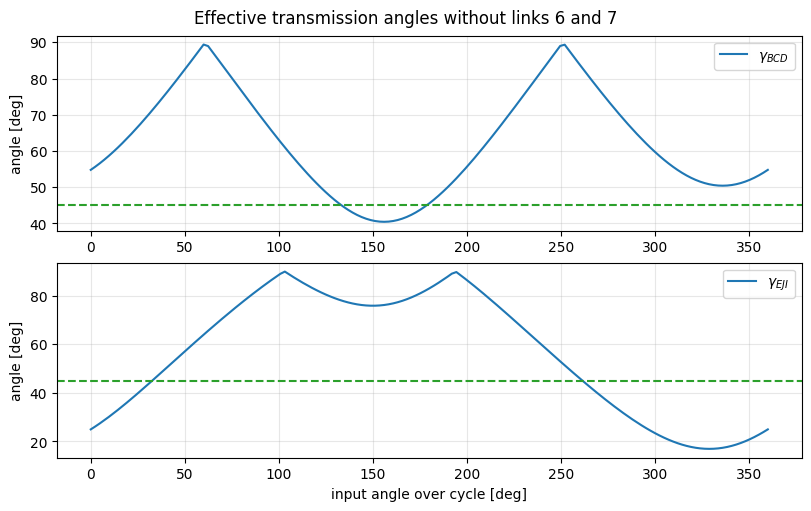

Minimum effective transmission angles
A-B-C-D: 40.46 deg
D-E-J-I: 16.92 deg


In [8]:
def effective_transmission_angle(theta_a, theta_b):
    gamma = np.abs(theta_a - theta_b)
    gamma = np.mod(gamma, 2*np.pi)
    gamma = np.minimum(gamma, 2*np.pi - gamma)
    return np.minimum(gamma, np.pi - gamma)

gamma_BCD = effective_transmission_angle(theta2, theta3)
gamma_EJI = effective_transmission_angle(theta6, theta7)

theta1_cycle_deg = (theta1 - theta1[0]) * 180/np.pi

fig_trans, ax_trans = plt.subplots(nrows=2, ncols=1, constrained_layout=True, figsize=(8, 5))
fig_trans.suptitle('Effective transmission angles without links 6 and 7')
ax_trans[0].plot(theta1_cycle_deg, np.rad2deg(gamma_BCD), label=r'$\gamma_{BCD}$')
ax_trans[0].axhline(45, color='tab:green', linestyle='--')
ax_trans[0].set_ylabel('angle [deg]')
ax_trans[0].legend()
ax_trans[1].plot(theta1_cycle_deg, np.rad2deg(gamma_EJI), label=r'$\gamma_{EJI}$')
ax_trans[1].axhline(45, color='tab:green', linestyle='--')
ax_trans[1].set_ylabel('angle [deg]')
ax_trans[1].set_xlabel('input angle over cycle [deg]')
ax_trans[1].legend()
plt.show()

print('Minimum effective transmission angles')
print(f'A-B-C-D: {np.rad2deg(np.min(gamma_BCD)):.2f} deg')
print(f'D-E-J-I: {np.rad2deg(np.min(gamma_EJI)):.2f} deg')

In [9]:
# dynamic parameters, defined in a local frame on each of the bars:
X1 = r1 / 2
X2 = r2 / 2
X3 = r3 / 2 - rDF
X4 = r4 / 2
X5 = r5 / 2
X6 = 0.0
X7 = 0.0

Y1 = 0.0
Y2 = 0.0
Y3 = 0.0
Y4 = 0.0
Y5 = 0.0
Y6 = 0.0
Y7 = 0.0

diameter = 0.01
mass_per_length = 7850*np.pi*(diameter/2)**2
m1 = r1 * mass_per_length
m2 = r2 * mass_per_length
m3 = r3 * mass_per_length
m4 = r4 * mass_per_length
m5 = r5 * mass_per_length
m6 = 0.0
m7 = 0.0
m_total = m1 + m2 + m3 + m4 + m5

g = 9.81
cycle_time = t[-1] - t[0]
def cycle_average(signal):
    return np.trapezoid(signal, t) / cycle_time

J1 = m1 * r1**2 / 12
J2 = m2 * r2**2 / 12
J3 = m3 * r3**2 / 12
J4 = m4 * r4**2 / 12
J5 = m5 * r5**2 / 12
J6 = 0.0
J7 = 0.0

(
    vel_1x, vel_1y, vel_2x, vel_2y, vel_3x, vel_3y, vel_4x, vel_4y,
    vel_5x, vel_5y, vel_6x, vel_6y, vel_7x, vel_7y,
    v_1, v_2, v_3, v_4, v_5, v_6, v_7,
    acc_1x, acc_1y, acc_2x, acc_2y, acc_3x, acc_3y, acc_4x, acc_4y,
    acc_5x, acc_5y, acc_6x, acc_6y, acc_7x, acc_7y
) = center_of_mass_kinematics(
    theta1, theta2, theta3, theta4, theta5, theta6, theta7,
    dtheta1, dtheta2, dtheta3, dtheta4, dtheta5, dtheta6, dtheta7,
    ddtheta1, ddtheta2, ddtheta3, ddtheta4, ddtheta5, ddtheta6, ddtheta7,
    r1, r2, r3, r4, r5, r6, r7, rDC, rDF, rED, rIJ,
    X1, X2, X3, X4, X5, X6, X7,
    Y1, Y2, Y3, Y4, Y5, Y6, Y7
)

# wiper-blade friction on the windshield:
mu_wiper_glass = 0.60
normal_force_wiper = 3.0
v_regularisation = 1e-4

s_wiper_left = 0.5 * (r3 - rDF)
s_wiper_right = 0.5 * r5

vel_wiper_left_x = -s_wiper_left * np.sin(theta3) * dtheta3
vel_wiper_left_y =  s_wiper_left * np.cos(theta3) * dtheta3
vel_wiper_right_x = -s_wiper_right * np.sin(theta7) * dtheta7
vel_wiper_right_y =  s_wiper_right * np.cos(theta7) * dtheta7

speed_wiper_left = np.sqrt(vel_wiper_left_x**2 + vel_wiper_left_y**2)
speed_wiper_right = np.sqrt(vel_wiper_right_x**2 + vel_wiper_right_y**2)

F_wiper_left_x = -mu_wiper_glass * normal_force_wiper * vel_wiper_left_x / (speed_wiper_left + v_regularisation)
F_wiper_left_y = -mu_wiper_glass * normal_force_wiper * vel_wiper_left_y / (speed_wiper_left + v_regularisation)
F_wiper_right_x = -mu_wiper_glass * normal_force_wiper * vel_wiper_right_x / (speed_wiper_right + v_regularisation)
F_wiper_right_y = -mu_wiper_glass * normal_force_wiper * vel_wiper_right_y / (speed_wiper_right + v_regularisation)

wiper_left_cog_x = (s_wiper_left - X3) * np.cos(theta3) - Y3 * np.cos(theta3 + np.pi/2)
wiper_left_cog_y = (s_wiper_left - X3) * np.sin(theta3) - Y3 * np.sin(theta3 + np.pi/2)
wiper_right_cog_x = (s_wiper_right - X5) * np.cos(theta7) - Y5 * np.cos(theta7 + np.pi/2)
wiper_right_cog_y = (s_wiper_right - X5) * np.sin(theta7) - Y5 * np.sin(theta7 + np.pi/2)

M_wiper_left_cog = wiper_left_cog_x * F_wiper_left_y - wiper_left_cog_y * F_wiper_left_x
M_wiper_right_cog = wiper_right_cog_x * F_wiper_right_y - wiper_right_cog_y * F_wiper_right_x

# hinge friction in the revolute joints:
c_hinge = 0.010
M_c_hinge = 0.015
omega_regularisation = 1e-3

def hinge_friction_torque(omega_rel):
    return -c_hinge * omega_rel - M_c_hinge * np.tanh(omega_rel / omega_regularisation)

M_hinge_1 = hinge_friction_torque(dtheta1)  # A
M_hinge_2 = np.zeros_like(t)
M_hinge_3 = hinge_friction_torque(dtheta3)  # D
M_hinge_4 = np.zeros_like(t)
M_hinge_5 = hinge_friction_torque(dtheta7)  # I
M_hinge_6 = np.zeros_like(t)
M_hinge_7 = np.zeros_like(t)

def add_internal_hinge_friction(M_i, M_j, omega_i, omega_j):
    torque_on_j = hinge_friction_torque(omega_j - omega_i)
    return M_i - torque_on_j, M_j + torque_on_j

M_hinge_1, M_hinge_2 = add_internal_hinge_friction(M_hinge_1, M_hinge_2, dtheta1, dtheta2)  # B
M_hinge_2, M_hinge_3 = add_internal_hinge_friction(M_hinge_2, M_hinge_3, dtheta2, dtheta3)  # C
M_hinge_3, M_hinge_4 = add_internal_hinge_friction(M_hinge_3, M_hinge_4, dtheta3, dtheta6)  # E
M_hinge_4, M_hinge_5 = add_internal_hinge_friction(M_hinge_4, M_hinge_5, dtheta6, dtheta7)  # J

print(f'Total moving mass without links 6 and 7: {m_total:.3f} kg')
print(f'Mean blade friction power loss: {-cycle_average(F_wiper_left_x*vel_wiper_left_x + F_wiper_left_y*vel_wiper_left_y + F_wiper_right_x*vel_wiper_right_x + F_wiper_right_y*vel_wiper_right_y):.3g} W')

Total moving mass without links 6 and 7: 2.941 kg
Mean blade friction power loss: 4.12 W


In [10]:
# formulas for inverse dynamics:
def dynamics_ruitenwissers(theta1, theta2, theta3, theta4, theta5, theta6, theta7,
                           dtheta1, dtheta2, dtheta3, dtheta4, dtheta5, dtheta6, dtheta7,
                           ddtheta1, ddtheta2, ddtheta3, ddtheta4, ddtheta5, ddtheta6, ddtheta7,
                           r1, r2, r3, r4, r5, r6, r7, rDC, rDF, rED, rIJ,
                           m1, m2, m3, m4, m5, m6, m7, g,
                           X1, X2, X3, X4, X5, X6, X7,
                           Y1, Y2, Y3, Y4, Y5, Y6, Y7,
                           J1, J2, J3, J4, J5, J6, J7,
                           acc_1x, acc_1y, acc_2x, acc_2y, acc_3x, acc_3y, acc_4x, acc_4y,
                           acc_5x, acc_5y, acc_6x, acc_6y, acc_7x, acc_7y,
                           F_wiper_left_x, F_wiper_left_y, F_wiper_right_x, F_wiper_right_y,
                           M_wiper_left_cog, M_wiper_right_cog,
                           M_hinge_1, M_hinge_2, M_hinge_3, M_hinge_4,
                           M_hinge_5, M_hinge_6, M_hinge_7, t):
    cog1_A_x = -X1*np.cos(theta1) - Y1*np.cos(theta1 + np.pi/2)
    cog1_A_y = -X1*np.sin(theta1) - Y1*np.sin(theta1 + np.pi/2)
    cog1_B_x = (r1 - X1)*np.cos(theta1) - Y1*np.cos(theta1 + np.pi/2)
    cog1_B_y = (r1 - X1)*np.sin(theta1) - Y1*np.sin(theta1 + np.pi/2)

    cog2_B_x = -X2*np.cos(theta2) - Y2*np.cos(theta2 + np.pi/2)
    cog2_B_y = -X2*np.sin(theta2) - Y2*np.sin(theta2 + np.pi/2)
    cog2_C_x = (r2 - X2)*np.cos(theta2) - Y2*np.cos(theta2 + np.pi/2)
    cog2_C_y = (r2 - X2)*np.sin(theta2) - Y2*np.sin(theta2 + np.pi/2)

    cog3_C_x = (-rDC - X3)*np.cos(theta3) - Y3*np.cos(theta3 + np.pi/2)
    cog3_C_y = (-rDC - X3)*np.sin(theta3) - Y3*np.sin(theta3 + np.pi/2)
    cog3_D_x = -X3*np.cos(theta3) - Y3*np.cos(theta3 + np.pi/2)
    cog3_D_y = -X3*np.sin(theta3) - Y3*np.sin(theta3 + np.pi/2)
    cog3_E_x = (rED - X3)*np.cos(theta3) - Y3*np.cos(theta3 + np.pi/2)
    cog3_E_y = (rED - X3)*np.sin(theta3) - Y3*np.sin(theta3 + np.pi/2)

    cog4_E_x = -X4*np.cos(theta6) - Y4*np.cos(theta6 + np.pi/2)
    cog4_E_y = -X4*np.sin(theta6) - Y4*np.sin(theta6 + np.pi/2)
    cog4_J_x = (r4 - X4)*np.cos(theta6) - Y4*np.cos(theta6 + np.pi/2)
    cog4_J_y = (r4 - X4)*np.sin(theta6) - Y4*np.sin(theta6 + np.pi/2)

    cog5_I_x = -X5*np.cos(theta7) - Y5*np.cos(theta7 + np.pi/2)
    cog5_I_y = -X5*np.sin(theta7) - Y5*np.sin(theta7 + np.pi/2)
    cog5_J_x = (rIJ - X5)*np.cos(theta7) - Y5*np.cos(theta7 + np.pi/2)
    cog5_J_y = (rIJ - X5)*np.sin(theta7) - Y5*np.sin(theta7 + np.pi/2)

    t_size = len(t)
    F_A_x = np.zeros_like(t); F_A_y = np.zeros_like(t)
    F_B_x = np.zeros_like(t); F_B_y = np.zeros_like(t)
    F_C_x = np.zeros_like(t); F_C_y = np.zeros_like(t)
    F_D_x = np.zeros_like(t); F_D_y = np.zeros_like(t)
    F_E_x = np.zeros_like(t); F_E_y = np.zeros_like(t)
    F_F_x = np.zeros_like(t); F_F_y = np.zeros_like(t)
    F_G_x = np.zeros_like(t); F_G_y = np.zeros_like(t)
    F_H_x = np.zeros_like(t); F_H_y = np.zeros_like(t)
    F_I_x = np.zeros_like(t); F_I_y = np.zeros_like(t)
    F_J_x = np.zeros_like(t); F_J_y = np.zeros_like(t)
    M_A = np.zeros_like(t)

    for k in range(t_size):
        A = np.array([
            [1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
            [0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
            [0, 0, -1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
            [0, 0, 0, -1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, -1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, 0, -1, 0, 1, 0, 1, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, 0, 0, 0, 0, -1, 0, 1, 0, 0, 0, 0],
            [0, 0, 0, 0, 0, 0, 0, 0, 0, -1, 0, 1, 0, 0, 0],
            [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, -1, 0, 1, 0, 0],
            [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, -1, 0, 1, 0],
            [-cog1_A_y[k], cog1_A_x[k], -cog1_B_y[k], cog1_B_x[k], 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
            [0, 0, cog2_B_y[k], -cog2_B_x[k], -cog2_C_y[k], cog2_C_x[k], 0, 0, 0, 0, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, cog3_C_y[k], -cog3_C_x[k], -cog3_D_y[k], cog3_D_x[k], -cog3_E_y[k], cog3_E_x[k], 0, 0, 0, 0, 0],
            [0, 0, 0, 0, 0, 0, 0, 0, cog4_E_y[k], -cog4_E_x[k], -cog4_J_y[k], cog4_J_x[k], 0, 0, 0],
            [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, cog5_J_y[k], -cog5_J_x[k], -cog5_I_y[k], cog5_I_x[k], 0],
        ])

        B = np.array([
            m1*acc_1x[k],
            m1*acc_1y[k] + m1*g,
            m2*acc_2x[k],
            m2*acc_2y[k] + m2*g,
            m3*acc_3x[k] - F_wiper_left_x[k],
            m3*acc_3y[k] + m3*g - F_wiper_left_y[k],
            m4*acc_4x[k],
            m4*acc_4y[k] + m4*g,
            m5*acc_5x[k] - F_wiper_right_x[k],
            m5*acc_5y[k] + m5*g - F_wiper_right_y[k],
            J1*ddtheta1[k] - M_hinge_1[k],
            J2*ddtheta2[k] - M_hinge_2[k],
            J3*ddtheta3[k] - M_wiper_left_cog[k] - M_hinge_3[k],
            J4*ddtheta6[k] - M_hinge_4[k],
            J5*ddtheta7[k] - M_wiper_right_cog[k] - M_hinge_5[k],
        ])

        x = np.linalg.solve(A, B)
        F_A_x[k] = x[0];  F_A_y[k] = x[1]
        F_B_x[k] = x[2];  F_B_y[k] = x[3]
        F_C_x[k] = x[4];  F_C_y[k] = x[5]
        F_D_x[k] = x[6];  F_D_y[k] = x[7]
        F_E_x[k] = x[8];  F_E_y[k] = x[9]
        F_J_x[k] = x[10]; F_J_y[k] = x[11]
        F_I_x[k] = x[12]; F_I_y[k] = x[13]
        M_A[k] = x[14]

    return (F_A_x, F_B_x, F_C_x, F_D_x, F_E_x, F_F_x, F_G_x, F_H_x, F_I_x, F_J_x,
            F_A_y, F_B_y, F_C_y, F_D_y, F_E_y, F_F_y, F_G_y, F_H_y, F_I_y, F_J_y, M_A)

F_A_x = np.zeros_like(t); F_A_y = np.zeros_like(t)
F_B_x = np.zeros_like(t); F_B_y = np.zeros_like(t)
F_C_x = np.zeros_like(t); F_C_y = np.zeros_like(t)
F_D_x = np.zeros_like(t); F_D_y = np.zeros_like(t)
F_E_x = np.zeros_like(t); F_E_y = np.zeros_like(t)
F_F_x = np.zeros_like(t); F_F_y = np.zeros_like(t)
F_G_x = np.zeros_like(t); F_G_y = np.zeros_like(t)
F_H_x = np.zeros_like(t); F_H_y = np.zeros_like(t)
F_I_x = np.zeros_like(t); F_I_y = np.zeros_like(t)
F_J_x = np.zeros_like(t); F_J_y = np.zeros_like(t)
M_A = np.zeros_like(t)

(
    F_A_x, F_B_x, F_C_x, F_D_x, F_E_x, F_F_x, F_G_x, F_H_x, F_I_x, F_J_x,
    F_A_y, F_B_y, F_C_y, F_D_y, F_E_y, F_F_y, F_G_y, F_H_y, F_I_y, F_J_y, M_A
) = dynamics_ruitenwissers(
    theta1, theta2, theta3, theta4, theta5, theta6, theta7,
    dtheta1, dtheta2, dtheta3, dtheta4, dtheta5, dtheta6, dtheta7,
    ddtheta1, ddtheta2, ddtheta3, ddtheta4, ddtheta5, ddtheta6, ddtheta7,
    r1, r2, r3, r4, r5, r6, r7, rDC, rDF, rED, rIJ,
    m1, m2, m3, m4, m5, m6, m7, g,
    X1, X2, X3, X4, X5, X6, X7,
    Y1, Y2, Y3, Y4, Y5, Y6, Y7,
    J1, J2, J3, J4, J5, J6, J7,
    acc_1x, acc_1y, acc_2x, acc_2y, acc_3x, acc_3y, acc_4x, acc_4y,
    acc_5x, acc_5y, acc_6x, acc_6y, acc_7x, acc_7y,
    F_wiper_left_x, F_wiper_left_y, F_wiper_right_x, F_wiper_right_y,
    M_wiper_left_cog, M_wiper_right_cog,
    M_hinge_1, M_hinge_2, M_hinge_3, M_hinge_4,
    M_hinge_5, M_hinge_6, M_hinge_7, t
)

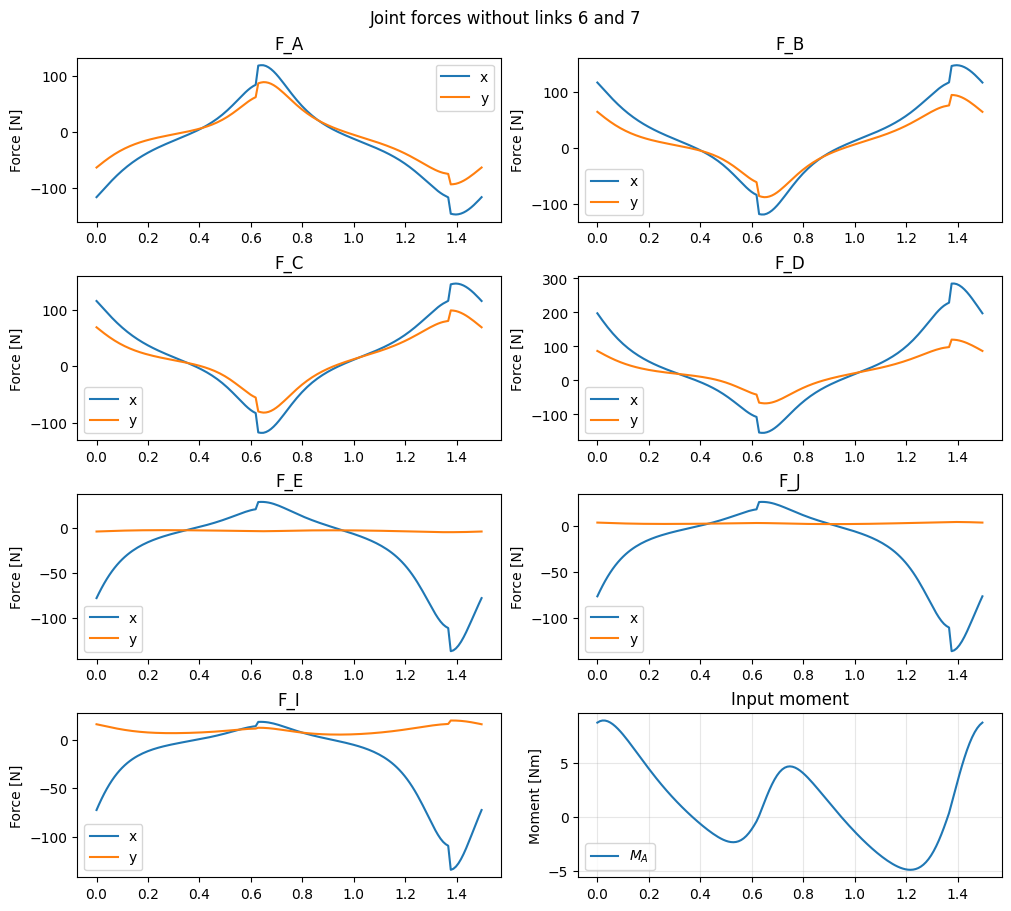

In [11]:
# plot forces and moment
force_plots = [
    ('A', F_A_x, F_A_y), ('B', F_B_x, F_B_y), ('C', F_C_x, F_C_y),
    ('D', F_D_x, F_D_y), ('E', F_E_x, F_E_y), ('J', F_J_x, F_J_y),
    ('I', F_I_x, F_I_y),
]
fig_forces, ax_forces = plt.subplots(nrows=4, ncols=2, constrained_layout=True, figsize=(10, 9))
fig_forces.suptitle('Joint forces without links 6 and 7')
for axis, (label, fx, fy) in zip(ax_forces.flat, force_plots):
    axis.plot(t, fx, label='x')
    axis.plot(t, fy, label='y')
    axis.set_title(f'F_{label}')
    axis.set_ylabel('Force [N]')
    axis.legend()
    axis.grid()
ax_forces.flat[-1].plot(t, M_A, label=r'$M_A$')
ax_forces.flat[-1].set_title('Input moment')
ax_forces.flat[-1].set_ylabel('Moment [Nm]')
ax_forces.flat[-1].legend()
plt.show()

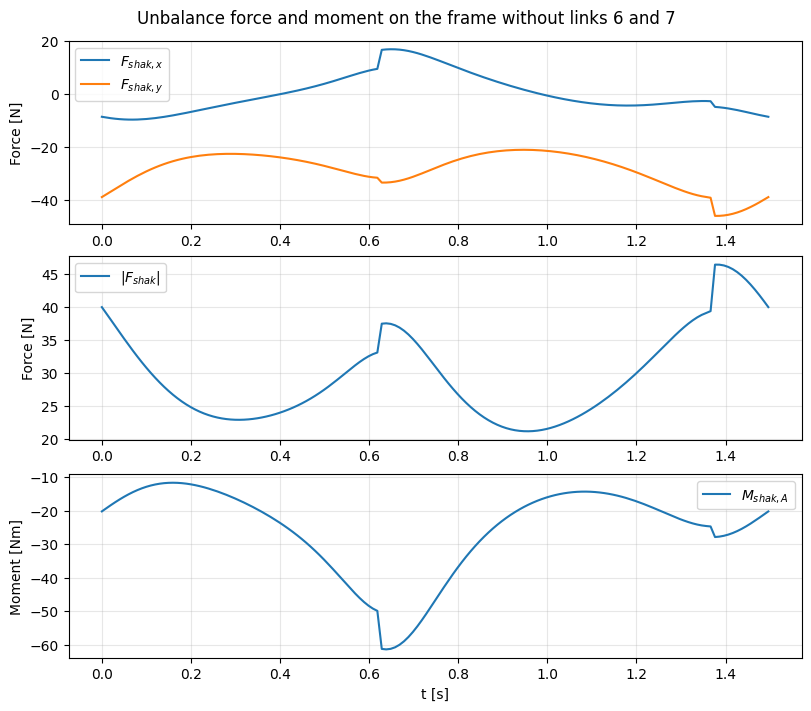

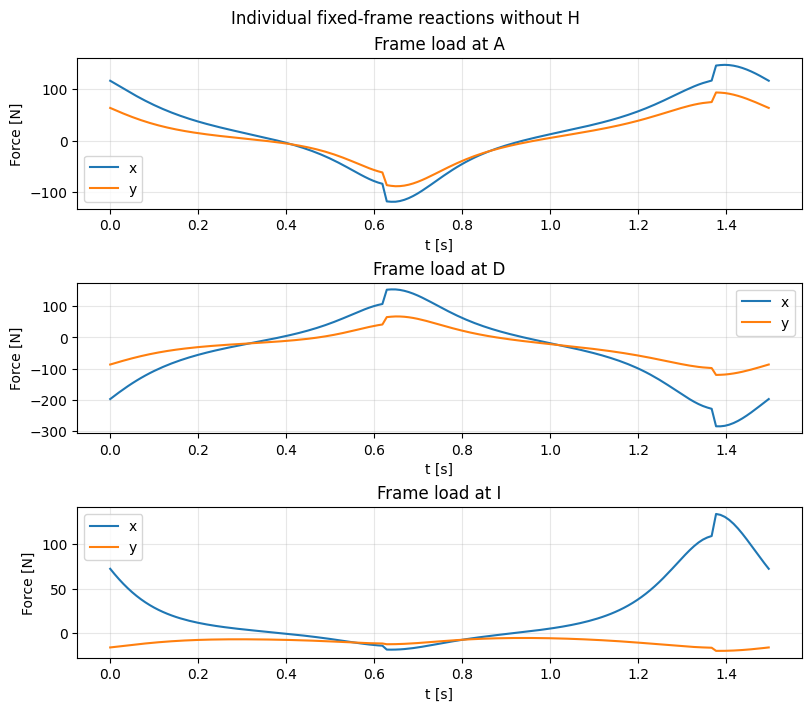

Unbalance summary without links 6 and 7
Peak |F_shak|:       46.5 N
Peak |M_shak,A|:     61.4 Nm
Peak |M_A|:          8.94 Nm
Moving mass:         2.94 kg


In [12]:
# Unbalance / shaking analysis:
# Zonder stang 6 en 7 zijn de vaste punten A, D en I actief.
# H is geen steunpunt meer en draagt dus geen framebelasting.
F_shak_x = -(F_A_x + F_D_x + F_I_x)
F_shak_y = -(F_A_y + F_D_y + F_I_y)
F_shak = np.sqrt(F_shak_x**2 + F_shak_y**2)

M_shak = -(
    grondA_x * F_A_y - grondA_y * F_A_x +
    grondD_x * F_D_y - grondD_y * F_D_x +
    grondI_x * F_I_y - grondI_y * F_I_x +
    M_A
)

fig_shak, ax_shak = plt.subplots(nrows=3, ncols=1, constrained_layout=True, figsize=(8, 7))
fig_shak.suptitle('Unbalance force and moment on the frame without links 6 and 7')

ax_shak[0].plot(t, F_shak_x, label=r'$F_{shak,x}$')
ax_shak[0].plot(t, F_shak_y, label=r'$F_{shak,y}$')
ax_shak[0].set_ylabel('Force [N]')
ax_shak[0].legend()

ax_shak[1].plot(t, F_shak, label=r'$|F_{shak}|$')
ax_shak[1].set_ylabel('Force [N]')
ax_shak[1].legend()

ax_shak[2].plot(t, M_shak, label=r'$M_{shak,A}$')
ax_shak[2].set_ylabel('Moment [Nm]')
ax_shak[2].set_xlabel('t [s]')
ax_shak[2].legend()
plt.show()

fixed_support_forces = [
    ('A', F_A_x, F_A_y),
    ('D', F_D_x, F_D_y),
    ('I', F_I_x, F_I_y),
]

fig_support, ax_support = plt.subplots(nrows=3, ncols=1, constrained_layout=True, figsize=(8, 7))
fig_support.suptitle('Individual fixed-frame reactions without H')
for axis, (label, force_x, force_y) in zip(ax_support.flat, fixed_support_forces):
    axis.plot(t, -force_x, label='x')
    axis.plot(t, -force_y, label='y')
    axis.set_title(f'Frame load at {label}')
    axis.set_ylabel('Force [N]')
    axis.set_xlabel('t [s]')
    axis.legend()
plt.show()

print('Unbalance summary without links 6 and 7')
print(f'Peak |F_shak|:       {np.max(F_shak):.3g} N')
print(f'Peak |M_shak,A|:     {np.max(np.abs(M_shak)):.3g} Nm')
print(f'Peak |M_A|:          {np.max(np.abs(M_A)):.3g} Nm')
print(f'Moving mass:         {m_total:.3g} kg')

In [13]:
# Vergelijking met het volledige mechanisme bij dezelfde r2 = 0.99 m en omega = 4.2 rad/s.
# Deze referentiewaarden komen uit de oorspronkelijke notebook met stang 6 en 7 aanwezig.
reference_full = {
    'moving mass [kg]': 3.804,
    'peak |F_shak| [N]': 53.23,
    'peak |M_shak,A| [Nm]': 72.40,
    'peak |M_A| [Nm]': 9.06,
}
without_67 = {
    'moving mass [kg]': m_total,
    'peak |F_shak| [N]': np.max(F_shak),
    'peak |M_shak,A| [Nm]': np.max(np.abs(M_shak)),
    'peak |M_A| [Nm]': np.max(np.abs(M_A)),
}

print('Effect van stang 6 en 7 verwijderen')
print('grootheid | volledig | zonder 6 en 7 | verandering')
print('--- | ---: | ---: | ---:')
for key in reference_full:
    old = reference_full[key]
    new = without_67[key]
    change = 100 * (new - old) / old
    print(f'{key} | {old:.3g} | {new:.3g} | {change:+.1f}%')

Effect van stang 6 en 7 verwijderen
grootheid | volledig | zonder 6 en 7 | verandering
--- | ---: | ---: | ---:
moving mass [kg] | 3.8 | 2.94 | -22.7%
peak |F_shak| [N] | 53.2 | 46.5 | -12.7%
peak |M_shak,A| [Nm] | 72.4 | 61.4 | -15.2%
peak |M_A| [Nm] | 9.06 | 8.94 | -1.4%


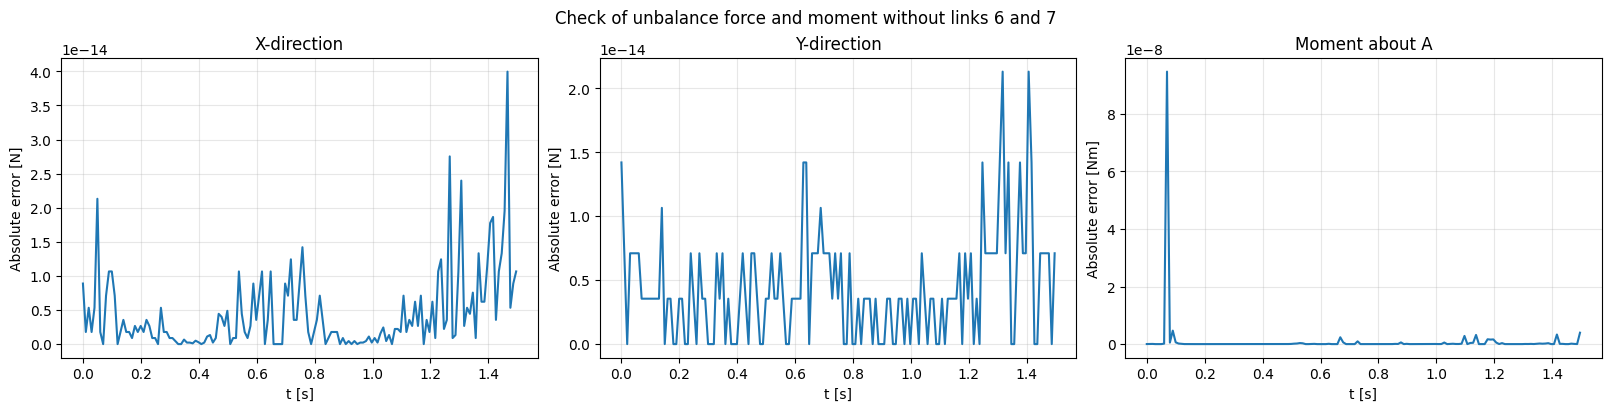

Max force-check error x: 4e-14 N
Max force-check error y: 2.13e-14 N
Max moment-check error:  9.47e-08 Nm


In [14]:
F_shak_x_check = -(
    m1 * acc_1x + m2 * acc_2x + m3 * acc_3x + m4 * acc_4x + m5 * acc_5x
) + F_wiper_left_x + F_wiper_right_x
F_shak_y_check = -(
    m1 * acc_1y + m2 * acc_2y + m3 * acc_3y + m4 * acc_4y + m5 * acc_5y
) - (m1 + m2 + m3 + m4 + m5) * g + F_wiper_left_y + F_wiper_right_y

(
    cog_1_x, cog_1_y, cog_2_x, cog_2_y, cog_3_x, cog_3_y,
    cog_4_x, cog_4_y, cog_5_x, cog_5_y, cog_6_x, cog_6_y,
    cog_7_x, cog_7_y
) = center_of_mass_positions(
    theta1, theta2, theta3, theta4, theta5, theta6, theta7,
    r1, rED, rDF,
    grondA_x, grondA_y, grondD_x, grondD_y, grondH_x, grondH_y, grondI_x, grondI_y,
    X1, X2, X3, X4, X5, X6, X7,
    Y1, Y2, Y3, Y4, Y5, Y6, Y7
)

M_inertia_about_A = (
    J1 * ddtheta1 + m1 * (cog_1_x * acc_1y - cog_1_y * acc_1x) +
    J2 * ddtheta2 + m2 * (cog_2_x * acc_2y - cog_2_y * acc_2x) +
    J3 * ddtheta3 + m3 * (cog_3_x * acc_3y - cog_3_y * acc_3x) +
    J4 * ddtheta6 + m4 * (cog_4_x * acc_4y - cog_4_y * acc_4x) +
    J5 * ddtheta7 + m5 * (cog_5_x * acc_5y - cog_5_y * acc_5x)
)

M_gravity_about_A = -g * (
    m1 * cog_1_x + m2 * cog_2_x + m3 * cog_3_x + m4 * cog_4_x + m5 * cog_5_x
)
M_wiper_about_A = (
    cog_3_x * F_wiper_left_y - cog_3_y * F_wiper_left_x + M_wiper_left_cog +
    cog_5_x * F_wiper_right_y - cog_5_y * F_wiper_right_x + M_wiper_right_cog
)
M_hinge_friction_about_A = M_hinge_1 + M_hinge_2 + M_hinge_3 + M_hinge_4 + M_hinge_5
M_shak_check = -M_inertia_about_A + M_gravity_about_A + M_wiper_about_A + M_hinge_friction_about_A

fig_check, axs = plt.subplots(1, 3, figsize=(16, 4), constrained_layout=True)
fig_check.suptitle('Check of unbalance force and moment without links 6 and 7')
axs[0].plot(t, abs(F_shak_x - F_shak_x_check))
axs[0].set_title('X-direction')
axs[0].set_ylabel('Absolute error [N]')
axs[0].set_xlabel('t [s]')
axs[1].plot(t, abs(F_shak_y - F_shak_y_check))
axs[1].set_title('Y-direction')
axs[1].set_ylabel('Absolute error [N]')
axs[1].set_xlabel('t [s]')
axs[2].plot(t, abs(M_shak - M_shak_check))
axs[2].set_title('Moment about A')
axs[2].set_ylabel('Absolute error [Nm]')
axs[2].set_xlabel('t [s]')
plt.show()

print(f'Max force-check error x: {np.max(abs(F_shak_x - F_shak_x_check)):.3g} N')
print(f'Max force-check error y: {np.max(abs(F_shak_y - F_shak_y_check)):.3g} N')
print(f'Max moment-check error:  {np.max(abs(M_shak - M_shak_check)):.3g} Nm')

## Interpretatie

Door stang 6 en 7 te verwijderen verdwijnt de vaste reactie in `H` en verdwijnt ook de massa/inertie van die twee stangen. De globale onbalanskracht wordt daardoor bepaald door de reacties in `A`, `D` en `I`.

Voor dezelfde `r2 = 0.99 m` en `omega = 4.2 rad/s` daalt de bewegende massa van ongeveer `3.80 kg` naar `2.94 kg`. In de berekening daalt de piek van de onbalanskracht van ongeveer `53 N` naar `46 N`, en het onbalansmoment van ongeveer `72 Nm` naar `61 Nm`. Het aandrijfmoment verandert weinig. Kwalitatief betekent dit dat stang 6 en 7 wel bijdragen aan de globale onbalans, maar niet de dominante oorzaak zijn van het aandrijfmoment.